# NB01 — Data Assembly & Response Variable

**Project:** `euk_in_prok_correlates` — metadata correlates of eukaryotic contamination in NMDC prokaryote-targeted metagenomes.

The per-sample analysis table is produced by `src/build_analysis_table.py` (heavy Spark aggregation over
`kbase.nmdc_arkin.{gottcha,kraken,centrifuge}_gold`, bridged to `nmdc.metadata.biosample_set`). This notebook
loads that frozen table, defines the response variables, cleans the predictors, and characterises the
eukaryotic-fraction distribution. See `data/00_feasibility_findings.md` and `memories/pitfalls.md` for provenance.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
DATA = Path('../data'); FIG = Path('../figures'); FIG.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi':110, 'savefig.bbox':'tight', 'axes.grid':True, 'grid.alpha':.3})

at = pd.read_csv(DATA/'analysis_table.csv')
print('samples:', len(at), '| studies:', at.study_id.nunique())
at.head(3)

samples: 5871 | studies: 16


,sample_id,study_id,n_gott_files,gott_euk_frac,gott_plastid_frac,gott_euk_nonplastid_frac,krak_euk_frac,cent_euk_frac,env_medium_term_name,env_broad_scale_term_name,...,ecosystem_category,ecosystem_type,ecosystem_subtype,samp_collec_device,depth_m,host_taxid_term_name,host_name,geo_loc,collection_date,platform
0,nmdc:bsm-11-002vgm56,nmdc:sty-11-34xj1150,1,0.207452,0.207452,0.0,0.006256,0.0,soil,terrestrial biome,...,Terrestrial,Soil,Unclassified,corer,NaN,NaN,NaN,"USA: Alaska, Healy",2016-07-26T01:30Z,NaN
1,nmdc:bsm-11-00esf117,nmdc:sty-11-5tgfr349,1,0.009874,0.009874,0.0,0.010974,0.0,sediment,freshwater river biome,...,Aquatic,Freshwater,River,NaN,NaN,NaN,NaN,"USA: Florida, Flamingo",2019-08-05,novaseq_6000
2,nmdc:bsm-11-00hrxp98,nmdc:sty-11-34xj1150,1,0.000000,0.000000,0.0,0.019028,0.0,soil,terrestrial biome,...,Terrestrial,Soil,Temperate forest,brownie cutter,NaN,NaN,NaN,"USA: Massachusetts, Harvard Forest & Quabbin W...",2016-08-03T19:07Z,NaN


## Response variables

- **`gott_euk_frac`** (primary): relative eukaryotic abundance (Eukaryota + plastid) from GOTTCHA2, superkingdom rank.
- **`gott_plastid_frac`**: plastid-only (plant/algal chloroplast) — the *plant* source.
- **`krak_euk_frac`**: Kraken2 Eukaryota (its DB resolves only Metazoa) — the *host/animal* source.
- **`cent_euk_frac`**: Centrifuge Eukaryota — retained only as a negative/robustness control (its DB barely resolves eukaryotes).

GOTTCHA is primary because the NMDC Kraken DB is prokaryote-restricted and understates total eukaryotic content
(see `memories/pitfalls.md`).

In [2]:
resp = ['gott_euk_frac','gott_plastid_frac','gott_euk_nonplastid_frac','krak_euk_frac','cent_euk_frac']
display(at[resp].describe().round(4))
# detection rates (fraction of samples with any signal)
det = (at[resp] > 0).mean().round(3)
print('\nDetection rate (frac samples with >0 signal):')
print(det.to_string())
print('\ncent_euk_frac max =', at.cent_euk_frac.max(), '-> Centrifuge does not resolve euk; dropped from analysis.')

,gott_euk_frac,gott_plastid_frac,gott_euk_nonplastid_frac,krak_euk_frac,cent_euk_frac
count,5871.0000,5871.0000,5871.0000,5871.0000,5867.0
mean,0.0660,0.0552,0.0108,0.0317,0.0
std,0.1769,0.1726,0.0518,0.0535,0.0
min,0.0000,0.0000,0.0000,0.0000,0.0
25%,0.0000,0.0000,0.0000,0.0097,0.0
50%,0.0000,0.0000,0.0000,0.0174,0.0
75%,0.0225,0.0000,0.0000,0.0324,0.0
max,1.0000,1.0000,1.0000,0.7621,0.0



Detection rate (frac samples with >0 signal):
gott_euk_frac               0.360
gott_plastid_frac           0.247
gott_euk_nonplastid_frac    0.113
krak_euk_frac               0.999
cent_euk_frac               0.000

cent_euk_frac max = 0.0 -> Centrifuge does not resolve euk; dropped from analysis.


## Predictor cleaning & matrix grouping

In [3]:
# Coarse matrix group from ecosystem_category; fine group from ecosystem_type.
at['matrix'] = at['ecosystem_category'].fillna('Unknown')
at['ecosystem_type'] = at['ecosystem_type'].fillna('Unknown')
at['env_medium'] = at['env_medium_term_name'].fillna('Unknown')
at['platform'] = at['platform'].fillna('Unknown')
at['log_depth'] = np.log10(at['depth_m'].fillna(0) + 1)
at['host_assoc'] = at['host_name'].notna() | at['host_taxid_term_name'].notna()
# detectable flag + logit-safe transform for the primary response
at['euk_detect'] = (at['gott_euk_frac'] > 0).astype(int)
eps = 1e-4
at['euk_logit'] = np.log((at['gott_euk_frac']+eps)/(1-at['gott_euk_frac']+eps))
print('matrix (ecosystem_category) counts:')
print(at['matrix'].value_counts().to_string())
print('\noverall euk detection rate:', round(at['euk_detect'].mean(),3))

matrix (ecosystem_category) counts:
matrix
Terrestrial             4467
Unknown                  668
Aquatic                  571
Plants                   148
Artificial ecosystem      17

overall euk detection rate: 0.36


## Figure 1 — Eukaryotic-fraction distributions and source split

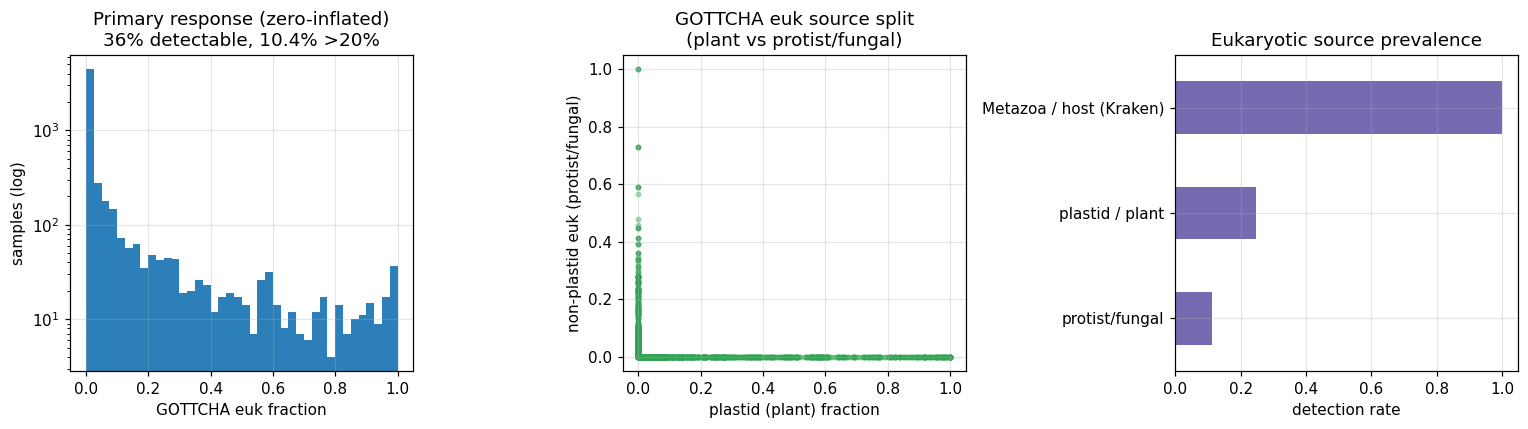

saved figures/fig01_euk_distributions.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
ax=axes[0]
ax.hist(at['gott_euk_frac'], bins=40, color='#2c7fb8')
ax.set_yscale('log'); ax.set_xlabel('GOTTCHA euk fraction'); ax.set_ylabel('samples (log)')
ax.set_title(f"Primary response (zero-inflated)\n{at['euk_detect'].mean()*100:.0f}% detectable, "
             f"{(at['gott_euk_frac']>0.2).mean()*100:.1f}% >20%")
ax=axes[1]
# source split among detectable samples
d = at[at['gott_euk_frac']>0]
ax.scatter(d['gott_plastid_frac'], d['gott_euk_frac']-d['gott_plastid_frac'], s=8, alpha=.4, color='#31a354')
ax.set_xlabel('plastid (plant) fraction'); ax.set_ylabel('non-plastid euk (protist/fungal)')
ax.set_title('GOTTCHA euk source split\n(plant vs protist/fungal)')
ax=axes[2]
srcs = pd.Series({'plastid / plant':(at['gott_plastid_frac']>0).mean(),
                  'protist/fungal':(at['gott_euk_nonplastid_frac']>0).mean(),
                  'Metazoa / host (Kraken)':(at['krak_euk_frac']>0).mean()})
srcs.sort_values().plot.barh(ax=ax, color='#756bb1')
ax.set_xlabel('detection rate'); ax.set_title('Eukaryotic source prevalence')
plt.tight_layout(); plt.savefig(FIG/'fig01_euk_distributions.png'); plt.show()
print('saved figures/fig01_euk_distributions.png')

## Classifier concordance (plant vs host measure different things)

In [5]:
sub = at[['gott_euk_frac','gott_plastid_frac','krak_euk_frac']].copy()
corr = sub.corr(method='spearman').round(2)
print('Spearman correlations among classifier signals:')
print(corr.to_string())
print('\nGOTTCHA (plant-dominated) and Kraken (host) are weakly correlated -> they capture')
print('complementary contamination sources, consistent with H1b (source attribution).')

Spearman correlations among classifier signals:
                   gott_euk_frac  gott_plastid_frac  krak_euk_frac
gott_euk_frac               1.00               0.78           0.24
gott_plastid_frac           0.78               1.00           0.28
krak_euk_frac               0.24               0.28           1.00

GOTTCHA (plant-dominated) and Kraken (host) are weakly correlated -> they capture
complementary contamination sources, consistent with H1b (source attribution).


## Save cleaned analysis table

In [6]:
keep = ['sample_id','study_id','n_gott_files','gott_euk_frac','gott_plastid_frac',
        'gott_euk_nonplastid_frac','krak_euk_frac','euk_detect','euk_logit',
        'matrix','ecosystem_type','ecosystem_subtype','env_medium','samp_collec_device',
        'platform','depth_m','log_depth','host_assoc','geo_loc']
clean = at[keep].copy()
clean.to_csv(DATA/'analysis_clean.csv', index=False)
print('wrote data/analysis_clean.csv', clean.shape)

wrote data/analysis_clean.csv (5871, 19)


## NB01 takeaways
- 5,871 NMDC metagenome samples with a GOTTCHA eukaryotic fraction; response is strongly **zero-inflated**.
- Eukaryotic signal is **plant/plastid-dominated**, with a smaller ubiquitous **host (Metazoa)** signal from Kraken.
- Plant and host signals are weakly correlated → they are distinct sources (motivates source-specific analysis in NB02).
- Centrifuge does not resolve eukaryotes and is dropped.
- Cleaned table saved for univariate tests (NB02) and modelling (NB03).